<a href="https://colab.research.google.com/github/sushilagarhari/Student-Placement-Prediction/blob/main/student_placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

data = {
    'cgpa': np.round(np.random.uniform(5.0, 9.5, n), 2),
    'internships': np.random.randint(0, 4, n),
    'projects': np.random.randint(0, 6, n),
    'certifications': np.random.randint(0, 5, n),
    'communication_skill': np.random.randint(1, 11, n),
    'backlogs': np.random.randint(0, 3, n),
}

df = pd.DataFrame(data)
df['placed'] = ((df['cgpa'] > 6.5) & (df['internships'] >= 1) & (df['backlogs'] == 0)).astype(int)

df.to_csv('student_placement.csv', index=False)
print(df.head())
print(f"\nTotal students: {len(df)}, Placed: {df['placed'].sum()}")

   cgpa  internships  projects  certifications  communication_skill  backlogs  \
0  6.69            0         4               0                    5         0   
1  9.28            3         3               4                    6         1   
2  8.29            3         5               3                    5         1   
3  7.69            1         2               0                    7         0   
4  5.70            2         1               3                    2         2   

   placed  
0       0  
1       0  
2       0  
3       1  
4       0  

Total students: 300, Placed: 40


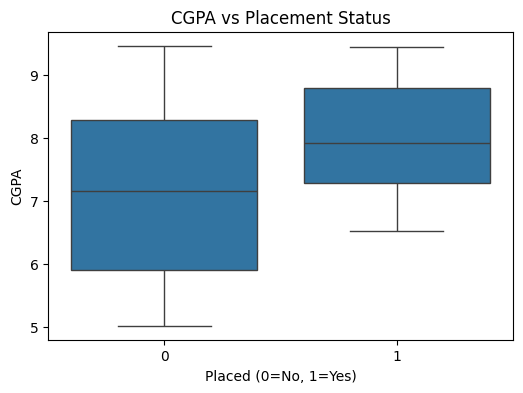

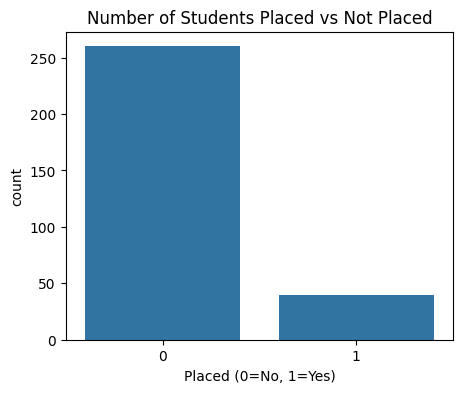

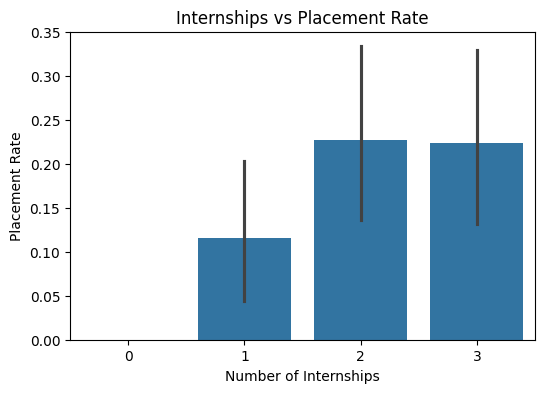

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph 1: CGPA vs Placement
plt.figure(figsize=(6,4))
sns.boxplot(x='placed', y='cgpa', data=df)
plt.title('CGPA vs Placement Status')
plt.xlabel('Placed (0=No, 1=Yes)')
plt.ylabel('CGPA')
plt.show()

# Graph 2: Placement Count
plt.figure(figsize=(5,4))
sns.countplot(x='placed', data=df)
plt.title('Number of Students Placed vs Not Placed')
plt.xlabel('Placed (0=No, 1=Yes)')
plt.show()

# Graph 3: Internships Impact
plt.figure(figsize=(6,4))
sns.barplot(x='internships', y='placed', data=df)
plt.title('Internships vs Placement Rate')
plt.xlabel('Number of Internships')
plt.ylabel('Placement Rate')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features aur target alag karo
X = df.drop('placed', axis=1)
y = df['placed']

# Train aur test data mein split karo (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model banao aur train karo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions karo
y_pred = model.predict(X_test)

# Accuracy check karo
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        11

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



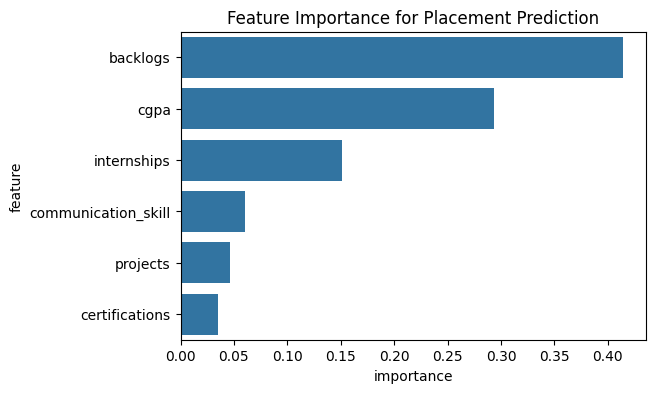

               feature  importance
5             backlogs    0.414601
0                 cgpa    0.293900
1          internships    0.150832
4  communication_skill    0.060057
2             projects    0.045997
3       certifications    0.034614


In [ ]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Feature Importance for Placement Prediction')
plt.show()
print(importance)

In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('placement_data')

import os
print(os.listdir('placement_data'))

['Placement_Data_Full_Class.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('placement_data/Placement_Data_Full_Class.csv')
print(df.shape)
print(df.head())
print(df.info())

(215, 15)
   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status    salary  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  270000.0  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  200000.0  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  250000.0  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed       NaN  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  425000.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Col

In [ ]:
# sl_no column hata do (sirf serial number hai, useful nahi)
df = df.drop('sl_no', axis=1)

# salary ki missing values ko 0 se bhar do (jo placed nahi hue unki salary 0)
df['salary'] = df['salary'].fillna(0)

# Text columns ko numbers mein convert karo
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
text_columns = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())
print("\nCleaning done! Shape:", df.shape)

   gender  ssc_p  ssc_b  hsc_p  hsc_b  hsc_s  degree_p  degree_t  workex  \
0       1  67.00      1  91.00      1      1     58.00         2       0   
1       1  79.33      0  78.33      1      2     77.48         2       1   
2       1  65.00      0  68.00      0      0     64.00         0       0   
3       1  56.00      0  52.00      0      2     52.00         2       0   
4       1  85.80      0  73.60      0      1     73.30         0       0   

   etest_p  specialisation  mba_p  status    salary  
0     55.0               1  58.80       1  270000.0  
1     86.5               0  66.28       1  200000.0  
2     75.0               0  57.80       1  250000.0  
3     66.0               1  59.43       0       0.0  
4     96.8               0  55.50       1  425000.0  

Cleaning done! Shape: (215, 14)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features aur target alag karo
# 'status' hi target hai (placed=1, not placed=0)
# 'salary' ko bhi hata do features se, kyunki wo status ka result hai, cause nahi
X = df.drop(['status', 'salary'], axis=1)
y = df['status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict karo
y_pred = model.predict(X_test)

# Accuracy check karo
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 79.07%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        12
           1       0.82      0.90      0.86        31

    accuracy                           0.79        43
   macro avg       0.75      0.70      0.72        43
weighted avg       0.78      0.79      0.78        43



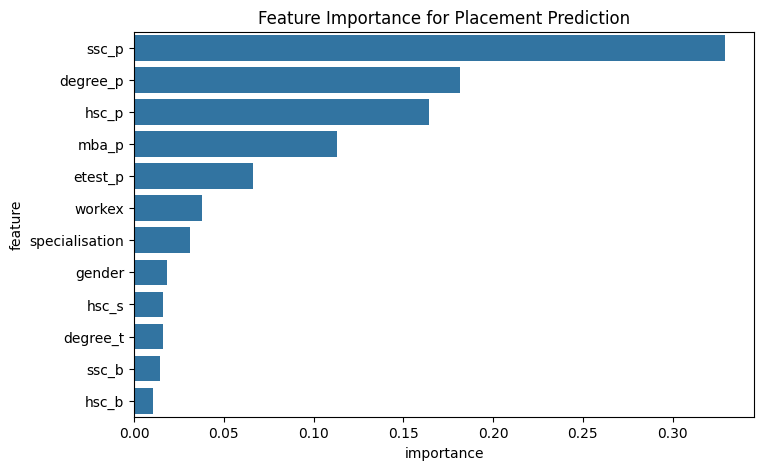

           feature  importance
1            ssc_p    0.328940
6         degree_p    0.181838
3            hsc_p    0.164455
11           mba_p    0.113255
9          etest_p    0.066270
8           workex    0.037812
10  specialisation    0.031081
0           gender    0.018445
5            hsc_s    0.016377
7         degree_t    0.016129
2            ssc_b    0.014603
4            hsc_b    0.010797


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Feature Importance for Placement Prediction')
plt.show()
print(importance)